# Task 2: Interpolation

## Strategy

Each series has two types of missing data within the observed window (rows 0-5255):

1. **Isolated single-day NaNs** at rows 35, 1193, 2835, 3429, 4117 (spike-cleaned, all series simultaneously) -- filled with **linear interpolation** (`limit=1`).

2. **One 50-day contiguous gap per series** (staggered, so all other six series are fully observed during each gap) -- filled with **OLS regression in log-return space** using contemporaneous returns of the other series as features, with a **Brownian bridge** correction to anchor the path at both endpoints.

| Series | Gap rows |
|---|---|
| gurkor | 198-247 |
| guitars | 398-447 |
| slingshots | 598-647 |
| stocks | 798-847 |
| sugar | 998-1047 |
| water | 1198-1247 |
| tranquillity | 1398-1447 |

**Key insight from Task 1:** `gurkor`/`water` (rho~0.58) and `guitars`/`slingshots` (rho~0.53) are strongly correlated, giving the best interpolation accuracy. `stocks` is nearly uncorrelated with all others, so its gap will rely on a noisier fit.

**No data leakage:** since this is interpolation (data exists on both sides of each gap), regression models are trained on data from *both sides* of the gap. This differs from Task 3 (extrapolation), where only pre-gap data is available.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('spiff_data2.csv', index_col=0)
cols = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

for col in cols:
    df.loc[df[col] == 1000, col] = np.nan

OBS_END = 5255
df_obs = df.loc[:OBS_END].copy()

print(f'Observed window: {len(df_obs)} rows')
print('Extrapolation tail: rows 5256-5455 (Task 3 only)')


Observed window: 5256 rows
Extrapolation tail: rows 5256-5455 (Task 3 only)


## Step 1 - Fill isolated single-day NaNs

Five rows are NaN in **all** series simultaneously (spike-cleaned values). Linear interpolation with `limit=1` fills only runs of length 1, leaving the 50-day gaps untouched.

In [30]:
df_filled = df_obs.copy()
for col in cols:
    df_filled[col] = df_filled[col].interpolate(method='linear', limit=1)

print('Remaining NaN counts after single-day fill (50-day gaps still intact):')
print(df_filled[cols].isna().sum())


Remaining NaN counts after single-day fill (50-day gaps still intact):
gurkor          49
guitars         49
slingshots      49
stocks          49
sugar           49
water           49
tranquillity    49
dtype: int64


## Step 2 - OLS regression with Brownian bridge for the 50-day gaps

### Model

For series X with gap at rows [t0, t1] we fit:

    r_t^(X) = b0 + sum_{j != X} b_j * r_t^(j) + eps_t,   eps_t ~ N(0, sigma^2)

Training uses all rows outside the gap (both before and after). During the gap, the six other series are observed, so we plug in their true contemporaneous returns as features. Only rows where all required columns (target + 6 predictors) are non-null are used for training.

### Brownian bridge

Since both the start price (row before gap) and end price (row after gap) are known, we apply a bridge correction: the total drift error between the OLS-predicted path and the true endpoint is spread evenly across all 50 predicted returns, so the path connects smoothly at both ends.

### Uncertainty

The daily-return noise std is the residual std `sigma`. Treating the gap returns as iid, the variance of the *cumulative* return after `i` steps is `i * sigma^2`. Because the path is pinned at both known endpoints, this is shrunk by a Brownian-bridge factor `(1 - i/n)`, so the band is zero at both ends and widest mid-gap (lens shape):

    cum_std(i) = sigma * sqrt( i * (1 - i/n) )

The 95% prediction interval is `p0 * exp(cum_ret +/- 1.96 * cum_std)` in price space.

(A finite-sample correction `sigma * sqrt(1 + x_t^T (X^T X)^{-1} x_t)` for having estimated the coefficients is available but negligible here — thousands of training rows — so it is omitted in this simpler version.)

In [31]:
gaps = {
    'gurkor':       (198,  247),
    'guitars':      (398,  447),
    'slingshots':   (598,  647),
    'stocks':       (798,  847),
    'sugar':        (998,  1047),
    'water':        (1198, 1247),
    'tranquillity': (1398, 1447),
}

log_ret = np.log(df_filled[cols]).diff()


def ols_interpolate(col, gap_start, gap_end, log_ret, cols):
    other = [c for c in cols if c != col]
    required = [col] + other

    before = log_ret.loc[:gap_start - 1].dropna(subset=required)
    after  = log_ret.loc[gap_end + 1:].dropna(subset=required)
    train  = pd.concat([before, after])

    X_tr, y_tr = train[other].values, train[col].values

    model = LinearRegression().fit(X_tr, y_tr)
    resid = y_tr - model.predict(X_tr)
    n, k  = X_tr.shape
    sigma = np.sqrt(np.sum(resid**2) / (n - k - 1))   # residual std = noise level of eps_t
    r2    = 1 - np.sum(resid**2) / np.sum((y_tr - y_tr.mean())**2)

    X_gap  = log_ret.loc[gap_start:gap_end, other].values
    y_pred = model.predict(X_gap)

    return y_pred, sigma, r2


def reconstruct_prices(df_filled, col, gap_start, gap_end, y_pred, sigma):
    p0 = df_filled.loc[gap_start - 1, col]
    p1 = df_filled.loc[gap_end + 1, col]

    # Brownian bridge correction
    n          = len(y_pred)
    total_ols  = np.sum(y_pred)
    total_true = np.log(p1 / p0)
    correction = (total_true - total_ols) / n
    y_bridged  = y_pred + correction

    cum_ret = np.cumsum(y_bridged)
    prices  = p0 * np.exp(cum_ret)

    # Brownian-bridge std of the cumulative log-return path.
    # iid daily noise sigma  =>  variance after i steps is i * sigma^2;
    # the factor (1 - i/n) pins the band to zero at the known far endpoint,
    # giving the lens shape (zero at both ends, widest mid-gap).
    t       = np.arange(1, n + 1)
    cum_std = sigma * np.sqrt(t * (1.0 - t / n))

    lo = p0 * np.exp(cum_ret - 1.96 * cum_std)
    hi = p0 * np.exp(cum_ret + 1.96 * cum_std)

    return prices, lo, hi


print('Helper functions defined.')


Helper functions defined.


In [32]:
results = {}

print(f"{'Series':<15} {'Gap rows':<15} {'Train R2':>10} {'Residual sigma':>16}")
print('-' * 60)

for col, (gs, ge) in gaps.items():
    y_pred, sigma, r2 = ols_interpolate(col, gs, ge, log_ret, cols)
    prices, lo, hi = reconstruct_prices(df_filled, col, gs, ge, y_pred, sigma)
    results[col] = dict(gap_start=gs, gap_end=ge, y_pred=y_pred,
                        prices=prices, lo=lo, hi=hi, sigma=sigma, r2=r2)
    print(f'{col:<15} {gs}-{ge:<10} {r2:>10.4f} {sigma:>16.6f}')


Series          Gap rows          Train R2   Residual sigma
------------------------------------------------------------
gurkor          198-247            0.3480         0.003192
guitars         398-447            0.3342         0.012216
slingshots      598-647            0.2955         0.012510
stocks          798-847            0.0029         0.014887
sugar           998-1047           0.0506         0.014721
water           1198-1247           0.3447         0.002839
tranquillity    1398-1447           0.0766         0.012280


## Step 3 - Validation (out-of-sample simulation)

To assess interpolation quality *before* knowing the true values, we simulate a synthetic 50-day gap 200 rows **after** each real gap (a fully observed region). The same OLS + bridge procedure is applied, and predictions are compared to the true values.

- **RMSE < Baseline RMSE**: model beats the naive zero-return forecast.
- **95% CI coverage ~ 0.95**: well-calibrated prediction intervals.

In [33]:
# Build log returns with real gaps filled so validation feature windows are NaN-free
# (e.g. gurkor's validation window 447-496 overlaps guitars' real gap 398-447)
df_val = df_filled.copy()
for _col, _r in results.items():
    df_val.loc[_r['gap_start']:_r['gap_end'], _col] = _r['prices']
log_ret_val = np.log(df_val[cols]).diff()

print(f"{'Series':<15} {'RMSE':>10} {'95% coverage':>14} {'Baseline RMSE':>15}")
print('-' * 58)

val_results = {}

for col, (gs, ge) in gaps.items():
    gap_len = ge - gs + 1
    v_start = ge + 200
    v_end   = v_start + gap_len - 1
    if v_end > OBS_END:
        v_start = gs - gap_len - 200
        v_end   = v_start + gap_len - 1

    y_pred_v, sigma_v, _ = ols_interpolate(col, v_start, v_end, log_ret_val, cols)
    y_true = log_ret_val.loc[v_start:v_end, col].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred_v))
    cov  = np.mean(np.abs(y_true - y_pred_v) <= 1.96 * sigma_v)
    base = np.sqrt(np.mean(y_true**2))

    val_results[col] = dict(rmse=rmse, coverage=cov, base_rmse=base)
    print(f'{col:<15} {rmse:>10.5f} {cov:>14.3f} {base:>15.5f}')

print()
print('RMSE < Baseline RMSE  =>  model beats naive zero-return forecast')
print('Coverage ~ 0.95       =>  well-calibrated intervals')


Series                RMSE   95% coverage   Baseline RMSE
----------------------------------------------------------
gurkor             0.00387          0.880         0.00370
guitars            0.00903          0.980         0.00864
slingshots         0.01037          0.960         0.01055
stocks             0.01426          0.980         0.01423
sugar              0.01941          0.860         0.02016
water              0.00293          0.940         0.00477
tranquillity       0.00921          1.000         0.00916

RMSE < Baseline RMSE  =>  model beats naive zero-return forecast
Coverage ~ 0.95       =>  well-calibrated intervals


## Step 4 - Visualise interpolated gaps

Each panel shows 150 days of context on each side of the gap:
- **Blue**: observed prices
- **Orange line**: interpolated prices (Brownian bridge)
- **Shaded band**: 95% prediction interval (lens-shaped, pinned at both endpoints)

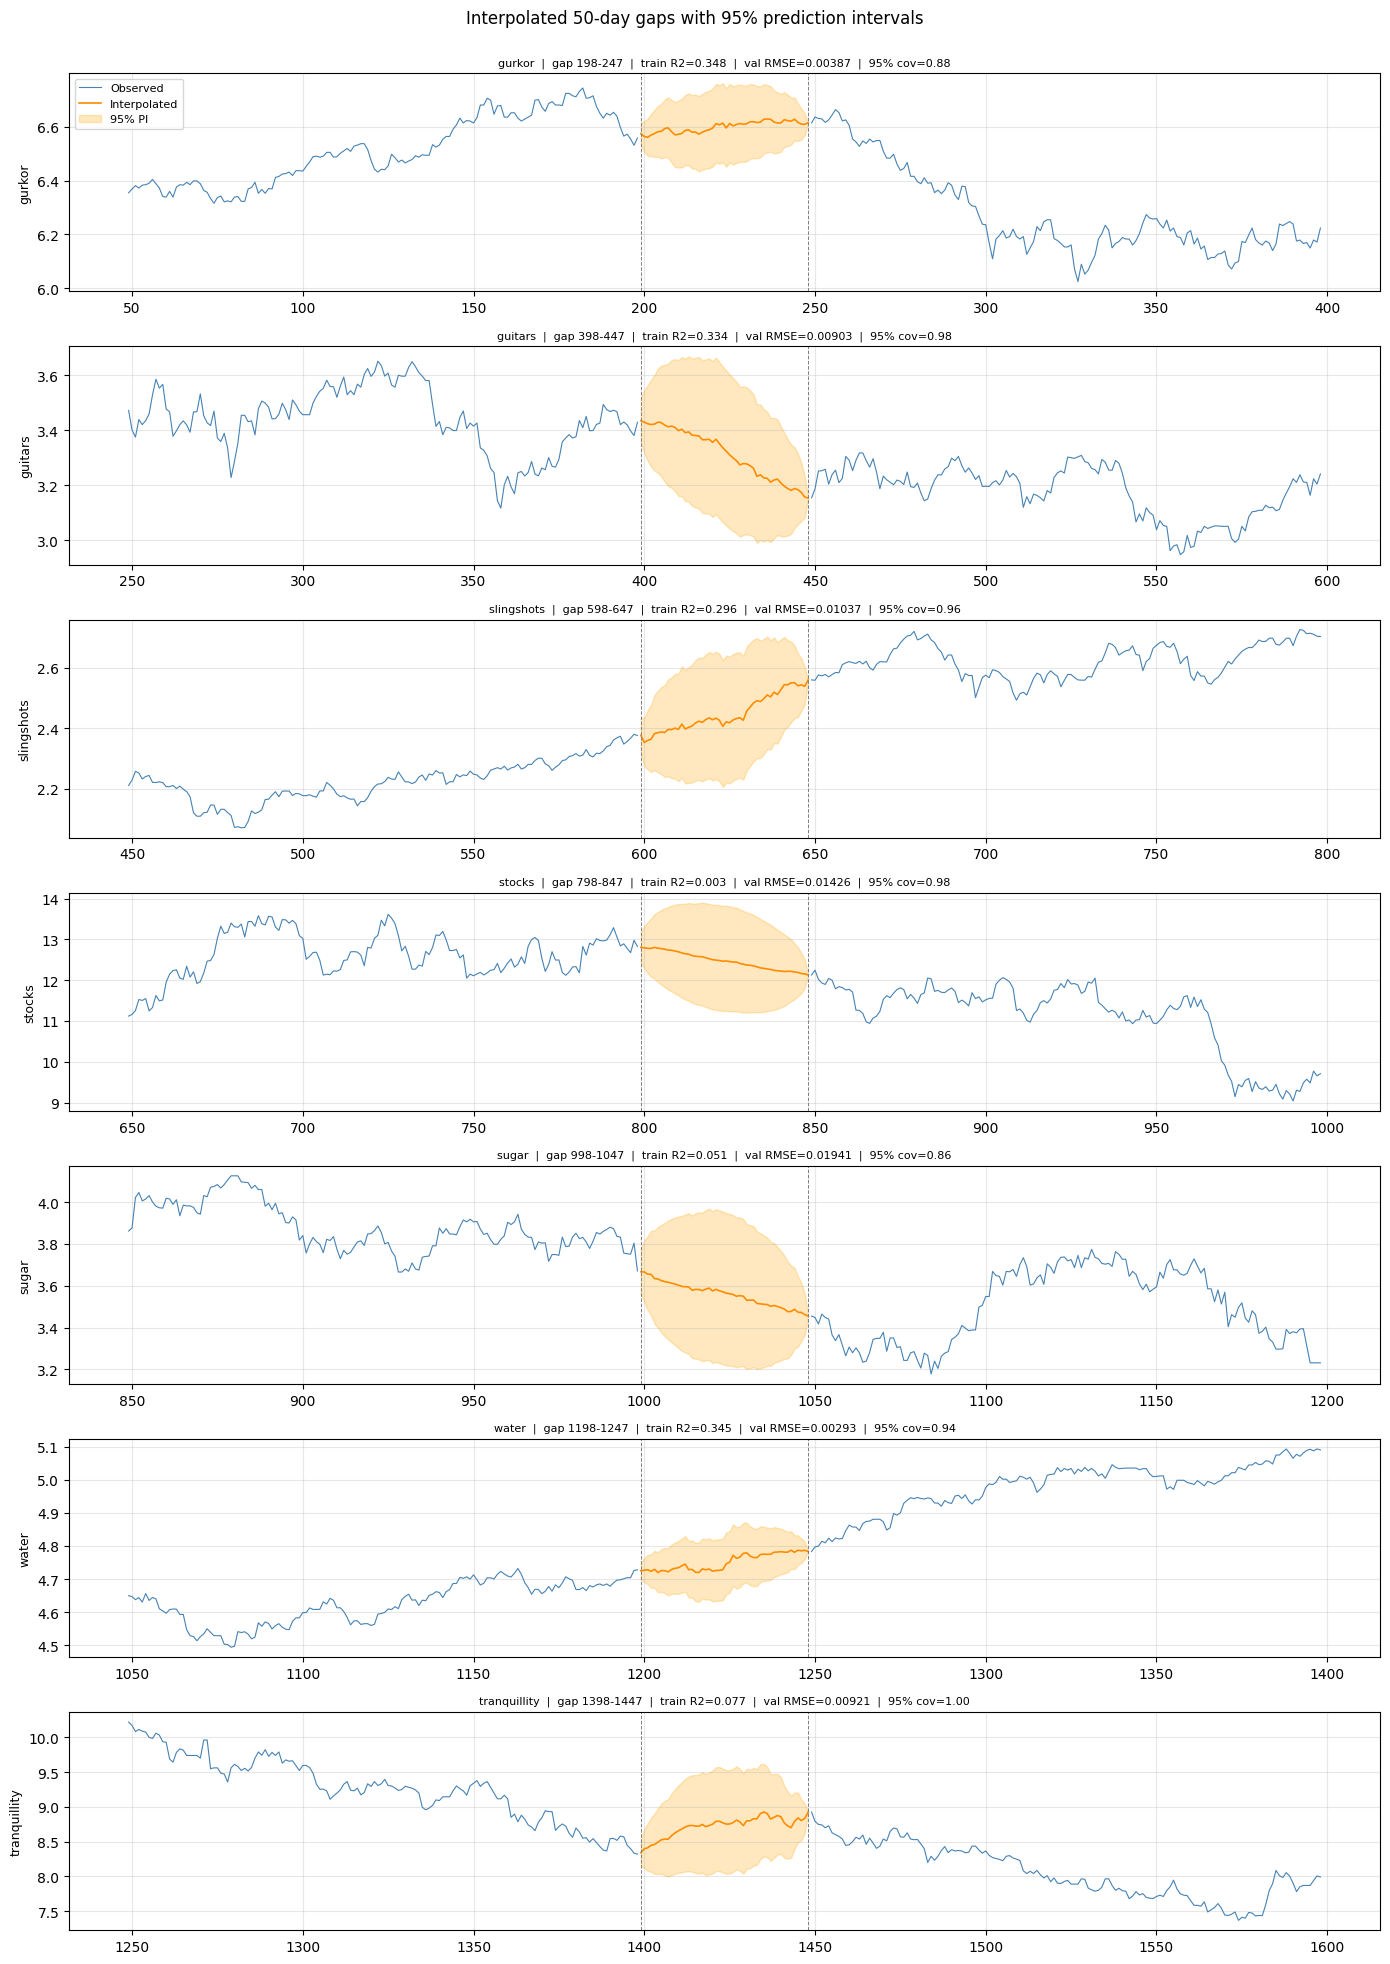

In [34]:
fig, axes = plt.subplots(7, 1, figsize=(14, 20))
context = 150

for ax, col in zip(axes, cols):
    r  = results[col]
    gs, ge = r['gap_start'], r['gap_end']
    ctx_s, ctx_e = max(0, gs - context), min(OBS_END, ge + context)

    ax.plot(df_filled.loc[ctx_s:gs-1, 'day'],
            df_filled.loc[ctx_s:gs-1, col],
            color='steelblue', lw=0.8, label='Observed')
    ax.plot(df_filled.loc[ge+1:ctx_e, 'day'],
            df_filled.loc[ge+1:ctx_e, col],
            color='steelblue', lw=0.8)

    gap_days = df_filled.loc[gs:ge, 'day'].values
    ax.plot(gap_days, r['prices'],
            color='darkorange', lw=1.2, label='Interpolated')
    ax.fill_between(gap_days, r['lo'], r['hi'],
                    color='orange', alpha=0.25, label='95% PI')
    ax.axvline(df_filled.loc[gs, 'day'], color='gray', ls='--', lw=0.7)
    ax.axvline(df_filled.loc[ge, 'day'], color='gray', ls='--', lw=0.7)

    vr = val_results[col]
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title(
        f"{col}  |  gap {gs}-{ge}  |  train R2={r['r2']:.3f}  |  val RMSE={vr['rmse']:.5f}  |  95% cov={vr['coverage']:.2f}", fontsize=8)

axes[0].legend(fontsize=8, loc='upper left')
fig.subplots_adjust(top=0.92)
fig.suptitle('Interpolated 50-day gaps with 95% prediction intervals', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Full series view

The same interpolation shown against each series' **entire observed history** (rows 0-5255), so the 50-day filled segment can be seen in context. The shaded vertical band marks the gap; the inset zooms in on it (gap +/- 80 days) with the orange median path and 95% interval.

As you can tell below, the gaps are rather small in relation to the entire dataset, almost to the point that a straight line from the gap start to the gap end could cut it as an approximation. More complex methods for modelling the interpolations were attempted but showed little value, with great risks of errors, capturing noise etc.

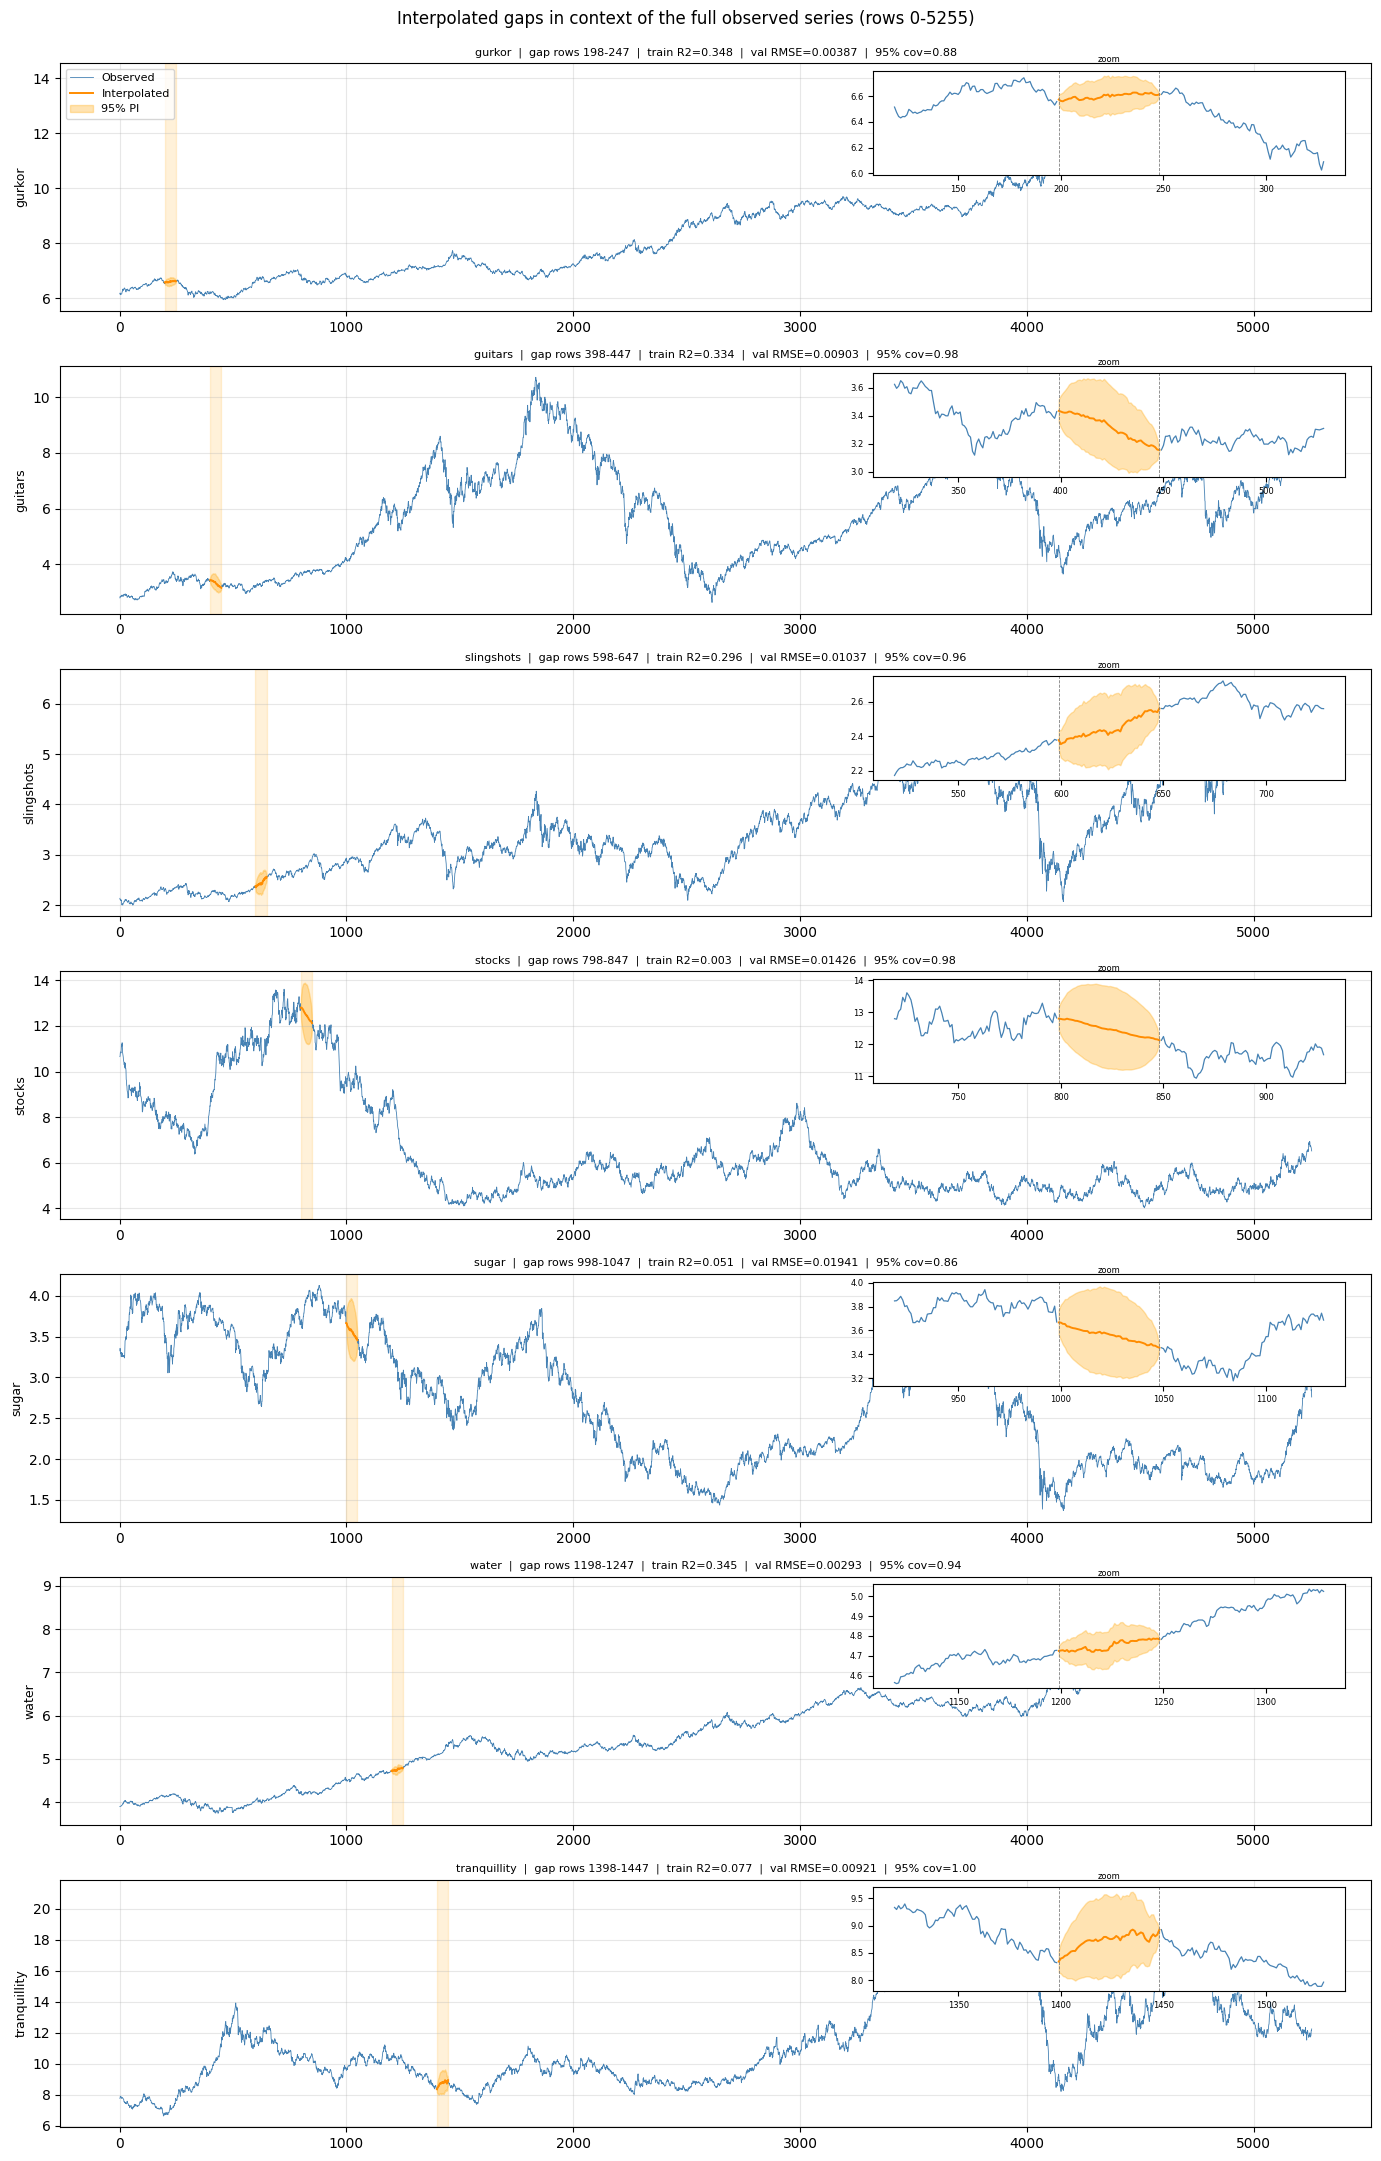

In [35]:
fig, axes = plt.subplots(7, 1, figsize=(14, 22))
zoom = 80  # days of context on each side in the inset

for ax, col in zip(axes, cols):
    r      = results[col]
    gs, ge = r['gap_start'], r['gap_end']
    day    = df_filled['day']

    # Full observed history (line breaks over the 50-day NaN gap automatically)
    ax.plot(day, df_filled[col], color='steelblue', lw=0.6, label='Observed')

    # Interpolated segment + 95% band
    gap_days = df_filled.loc[gs:ge, 'day'].values
    ax.plot(gap_days, r['prices'], color='darkorange', lw=1.4, label='Interpolated')
    ax.fill_between(gap_days, r['lo'], r['hi'], color='orange', alpha=0.3, label='95% PI')

    # Shade the gap so it's locatable on the full axis
    ax.axvspan(df_filled.loc[gs, 'day'], df_filled.loc[ge, 'day'],
               color='orange', alpha=0.15)

    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)
    vr = val_results[col]
    ax.set_title(f"{col}  |  gap rows {gs}-{ge}  |  train R2={r['r2']:.3f}  |  "
                 f"val RMSE={vr['rmse']:.5f}  |  95% cov={vr['coverage']:.2f}", fontsize=8)

    # Zoom inset around the gap
    z_s, z_e = max(0, gs - zoom), min(OBS_END, ge + zoom)
    axin = ax.inset_axes([0.62, 0.55, 0.36, 0.42])
    axin.plot(day.loc[z_s:gs-1], df_filled.loc[z_s:gs-1, col], color='steelblue', lw=0.9)
    axin.plot(day.loc[ge+1:z_e], df_filled.loc[ge+1:z_e, col], color='steelblue', lw=0.9)
    axin.plot(gap_days, r['prices'], color='darkorange', lw=1.4)
    axin.fill_between(gap_days, r['lo'], r['hi'], color='orange', alpha=0.3)
    axin.axvline(df_filled.loc[gs, 'day'], color='gray', ls='--', lw=0.6)
    axin.axvline(df_filled.loc[ge, 'day'], color='gray', ls='--', lw=0.6)
    axin.tick_params(labelsize=6)
    axin.set_title('zoom', fontsize=6)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Interpolated gaps in context of the full observed series (rows 0-5255)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


## Step 5 - Assemble and export the fully interpolated dataset

Write the filled prices back and save to CSV for Task 3.

In [36]:
df_interp = df_filled.copy()

for col, r in results.items():
    df_interp.loc[r['gap_start']:r['gap_end'], col] = r['prices']

print('NaN counts after full interpolation (should all be 0):')
print(df_interp[cols].isna().sum())

df_interp.to_csv('spiff_interpolated.csv')
print('Saved -> spiff_interpolated.csv')


NaN counts after full interpolation (should all be 0):
gurkor          0
guitars         0
slingshots      0
stocks          0
sugar           0
water           0
tranquillity    0
dtype: int64
Saved -> spiff_interpolated.csv


## Summary

| Gap type | Method |
|---|---|
| Single-day NaN (all series) | Linear interpolation (`limit=1`) |
| 50-day per-series gap | OLS regression in log-return space + Brownian bridge |

**Training data:** For interpolation, models are trained on data from both sides of each gap, since both sides are genuinely observed. Only rows where the target and all 6 predictor series are non-null are included.

**Brownian bridge:** The OLS-predicted returns are adjusted so the reconstructed price path lands exactly on the known endpoint. The drift error is spread uniformly across the gap.

**Expected performance:**
- **gurkor / water**: best accuracy (rho~0.58); highest R2
- **guitars / slingshots**: good accuracy (rho~0.53)
- **stocks**: nearly independent; wide PI reflects genuine unpredictability
- **sugar / tranquillity**: moderate correlations; intermediate accuracy

**Overfitting risk is minimal:** 6 features vs thousands of training rows, and financial returns are near-unpredictable by nature (low R2 is expected, not a flaw).

**Uncertainty:** The 95% PI forms a lens shape -- zero at both endpoints (known prices), widest at the midpoint. Band width is driven by residual sigma, which reflects the series' volatility and how well the other series explain it.